# Multiple lineare Regression zur Erklärung des Basispreises (USD)

## Ziel der multiplen Regression
Ziel dieses Notebooks ist die Untersuchung der Einflussfaktoren auf den Basispreis (USD) mittels multipler linearer Regression. Im Gegensatz zum Regressionsbaum steht hier die ökonomische Interpretierbarkeit der Koeffizienten im Vordergrund.


## Setup
### Imports, Pfade und Helper

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Pfade
ROOT = Path.cwd()

INPUT_RAW = ROOT / "input" / "raw"
INPUT_PROCESSED = ROOT / "input" / "processed"

OUT = ROOT / "output"
FIG_DIR = OUT / "figures"

FIG_MR = FIG_DIR / "modeling" / "multiple_regression"
FIG_MR.mkdir(parents=True, exist_ok=True)

for p in [INPUT_RAW, INPUT_PROCESSED, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATA_FILE = INPUT_PROCESSED / "mercedes_sales_processed.csv"



# Helper
def _slugify(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text if text else "Plot"


def _next_plot_number(fig_dir: Path) -> int:
    pattern = re.compile(r"^(\d{2,})\s+.*\.png$", re.IGNORECASE)
    nums = []
    for p in fig_dir.glob("*.png"):
        m = pattern.match(p.name)
        if m:
            nums.append(int(m.group(1)))
    return (max(nums) + 1) if nums else 1


plot_counter_mr = _next_plot_number(FIG_MR)


def save_current_plot_mr(dpi: int = 300):
    global plot_counter_mr

    fig = plt.gcf()
    if fig is None or len(fig.axes) == 0:
        print("Kein Plot zum Speichern")
        return

    title = plt.gca().get_title() or "plot"
    slug = _slugify(title)

    existing = list(FIG_MR.glob(f"* {slug}.png"))
    if existing:
        print(f"Übersprungen (Titel existiert bereits): {existing[0].name}")
        return

    filename = f"{plot_counter_mr:02d} {slug}.png"
    filepath = FIG_MR / filename

    fig.tight_layout()
    fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"Gespeichert: {filepath.name}")

    plot_counter_mr += 1

## Datenbasis

In [3]:
df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
df.head()

Shape: (12129513, 8)


,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Turbo
0,A-Class,2020,Global,Yellow,Diesel,41265,252,Yes
1,A-Class,2020,Global,Black,Petrol,51023,249,No
2,A-Class,2020,Global,Grey,Petrol,72819,341,Yes
3,A-Class,2020,Global,Black,Petrol,62480,385,Yes
4,A-Class,2020,Global,White,Petrol,35189,337,Yes


In [4]:
# Grundlegende Informationen
print("\nGrundlegende Informationen:")
df.info()

# Separate Listen für numerische und kategoriale Spalten erstellen
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"\nNumerische Spalten ({len(numeric_columns)}): {numeric_columns}")
print(f"Kategoriale Spalten ({len(categorical_columns)}): {categorical_columns}")

# Größe des Datensatzes
print(f"\nDatensatzgröße: {df.shape[0]} Zeilen und {df.shape[1]} Spalten")


Grundlegende Informationen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12129513 entries, 0 to 12129512
Data columns (total 8 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   Model             object
 1   Year              int64 
 2   Region            object
 3   Color             object
 4   Fuel Type         object
 5   Base Price (USD)  int64 
 6   Horsepower        int64 
 7   Turbo             object
dtypes: int64(3), object(5)
memory usage: 740.3+ MB

Numerische Spalten (3): ['Year', 'Base Price (USD)', 'Horsepower']
Kategoriale Spalten (5): ['Model', 'Region', 'Color', 'Fuel Type', 'Turbo']

Datensatzgröße: 12129513 Zeilen und 8 Spalten


In [5]:
# Zielvariable / Spaltennamen
df = df.rename(columns={
    "Base Price (USD)": "Base_USD",
    "Fuel Type": "Fuel_Type"
})

# Turbo binär
df["Turbo_bin"] = (df["Turbo"] == "Yes").astype("int8")

# Mapping-Check (optional
display(pd.crosstab(df["Turbo"], df["Turbo_bin"]))

# Speicher optimieren
cat_cols = ["Model", "Region", "Color", "Fuel_Type", "Turbo"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# int-Dtypes kleiner machen
df["Year"] = df["Year"].astype("int16")
df["Horsepower"] = df["Horsepower"].astype("int16")
df["Base_USD"] = df["Base_USD"].astype("int32")

df.info(memory_usage="deep")

Turbo_bin,0,1
Turbo,,
No,1761277,0
Yes,0,10368236


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12129513 entries, 0 to 12129512
Data columns (total 9 columns):
 #   Column      Dtype   
---  ------      -----   
 0   Model       category
 1   Year        int16   
 2   Region      category
 3   Color       category
 4   Fuel_Type   category
 5   Base_USD    int32   
 6   Horsepower  int16   
 7   Turbo       category
 8   Turbo_bin   int8    
dtypes: category(5), int16(2), int32(1), int8(1)
memory usage: 161.9 MB


## Modellierung

In [6]:
# Feature definieren
features_num = ["Year", "Horsepower", "Turbo_bin"]
features_cat = ["Fuel_Type", "Region", "Model"]

#One-Hot-Encoding
df_model = pd.get_dummies(
    df[features_num + features_cat + ["Base_USD"]],
    columns=features_cat,
    drop_first=True
)

# X und y
X = df_model.drop(columns="Base_USD")
y = df_model["Base_USD"]

# Trainings- und Testdaten (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

# Multiple lineare Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Vorhersage
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))


Trainingsdaten: (9703610, 22)
Testdaten: (2425903, 22)
R²: 0.7729
MAE: 23530.7
RMSE: 32326.34


- Trainingsdaten: 9.703.610 Beobachtungen / Testdaten: 2.425.903 Beobachtungen / 22 Variablen
- R²: 0,7729 -> ca. 77 % der Varianz des Basispreises erklärt
- MAE: 23.530,70 USD -> durchschnittliche absolute Abweichung
- RMSE: 32.326,33 USD -> weniger starke Abweichungen / reduzierte Ausreißerwirkung
- RMSE gewichtet große Fehler stärker als MAE
- preisbestimmende Faktoren sind im Modell berücksichtigt
- Variablen geeignet zur Analyse und Erklärung des Basispreises

In [7]:
# Adjusted R²
n = X_test.shape[0]   # Anzahl Testbeobachtungen
p = X_test.shape[1]   # Anzahl erklärender Variablen

# Adjusted R² berechnen
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

round(r2_adj,4)

0.7729

- Adjusted R² = 0.7729
- Keine relevante Differenz zum R²
- führt nicht zu künstlicher Modellverbesserung bei
- Modell zeigt strukturelle Stabilität

In [8]:
# Regressionskoeffizienten
coef_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    })
    .sort_values("Coefficient", ascending=False)
    .reset_index(drop=True)
)

# Top 5 positiv / negativ
top5 = coef_df.head(5).copy()
bottom5 = coef_df.tail(5).sort_values("Coefficient").copy()

# USD-Darstellung (deutsche Formatierung, ohne Dezimalstellen)
def format_usd(x):
    return f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

for df_tmp in (top5, bottom5):
    df_tmp["USD"] = df_tmp["Coefficient"].apply(format_usd)

display(top5[["Feature", "Coefficient", "USD"]])
display(bottom5[["Feature", "Coefficient", "USD"]])

,Feature,Coefficient,USD
0,Model_AMG A 45,188541.022709,"188.541,02"
1,Model_AMG GT,188537.027607,"188.537,03"
2,Model_AMG S 63,188282.164025,"188.282,16"
3,Model_S-Class,188105.759311,"188.105,76"
4,Model_AMG E 63,187956.195415,"187.956,20"


,Feature,Coefficient,USD
21,Model_CLA,-29.307251,"-29,31"
20,Model_GLA,-23.972262,"-23,97"
19,Model_E-Class,-9.193124,"-9,19"
18,Fuel_Type_Hybrid,-8.471383,"-8,47"
17,Model_GLB,-1.830468,"-1,83"


- Modellreihe dominiert den Basispreis deutlich
- AMG- und S-Class-Modelle → sehr hohe Preisaufschläge (~188.000 USD)
- Mittelklassemodelle -> nur geringe Preisabschläge
- Segmentstruktur wichtiger als einzelne technische Merkmale

### Prüfung der Modellannahmen – Multikollinearität (VIF)

In [9]:
# Für VIF nur numerische Matrix verwenden
X_vif = X.copy().astype(float)

# Stichprobe ziehen
X_vif = X.sample(n=100000, random_state=42).astype(float)

# VIF berechnen
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# sortieren
vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df["VIF"] = vif_df["VIF"].round(2)

vif_df

,Feature,VIF
0,Year,26.98
1,Horsepower,18.01
2,Turbo_bin,6.92
5,Fuel_Type_Petrol,3.25
18,Model_GLC,2.37
19,Model_GLE,2.28
11,Model_C-Class,2.02
14,Model_E-Class,1.93
4,Fuel_Type_Hybrid,1.92
16,Model_GLA,1.70


- Die meisten Prädiktoren weisen VIF-Werte unter 5 auf (unkritisch)
- Erhöhte Werte zeigen sich bei **Year (26,98)** und **Horsepower (18,01)**
- **Turbo_bin (6,92)** liegt im moderat erhöhten Bereich
- Zusammenhänge plausibel -> Year, Horsepower  und Modelle teilweise miteinander korrelieren
- Keine systematische oder verbreitete Multikollinearität im Modell erkennbar  
- Regressionsmodell insgesamt stabil und weiterhin sinnvoll interpretierbar

Gespeichert: 01 Durchschnittliche Vorhersage pro Preisgruppe.png


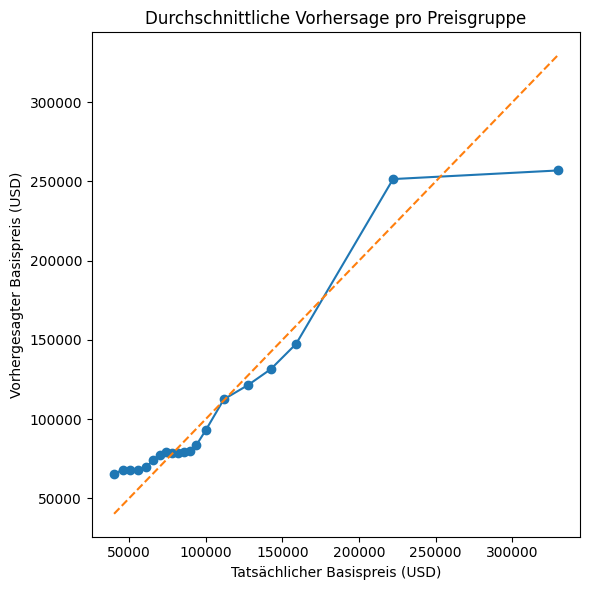

In [10]:
# Residuenanalyse
residuals = y_test - y_pred

y_true = y_test.to_numpy()
y_hat  = y_pred

df_plot = pd.DataFrame({
    "true": y_test,
    "pred": y_pred
})

# 20 gleich große Preisgruppen
df_plot["bin"] = pd.qcut(df_plot["true"], q=20, duplicates="drop")

binned = df_plot.groupby("bin", observed=True).agg(
    true_mean=("true","mean"),
    pred_mean=("pred","mean")
).reset_index()

plt.figure(figsize=(6,6))
plt.plot(binned["true_mean"], binned["pred_mean"], marker="o")

mn = min(binned["true_mean"].min(), binned["pred_mean"].min())
mx = max(binned["true_mean"].max(), binned["pred_mean"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.xlabel("Tatsächlicher Basispreis (USD)")
plt.ylabel("Vorhergesagter Basispreis (USD)")
plt.title("Durchschnittliche Vorhersage pro Preisgruppe")

save_current_plot_mr()

plt.tight_layout()
plt.show()

- Gestrichelte Linie = perfekte Vorhersage (y = x)  
- Untere und mittlere Preisbereiche nahe an der Diagonalen → gute Modellpassung  
- Im oberen Preissegment flacht die Kurve ab → systematische Unterschätzung sehr teurer Fahrzeuge  
- Preisniveaus werden insgesamt gut abgebildet  
- Differenzierung bei extrem hohen Basispreisen begrenzt

Gespeichert: 02 Residual Plot.png


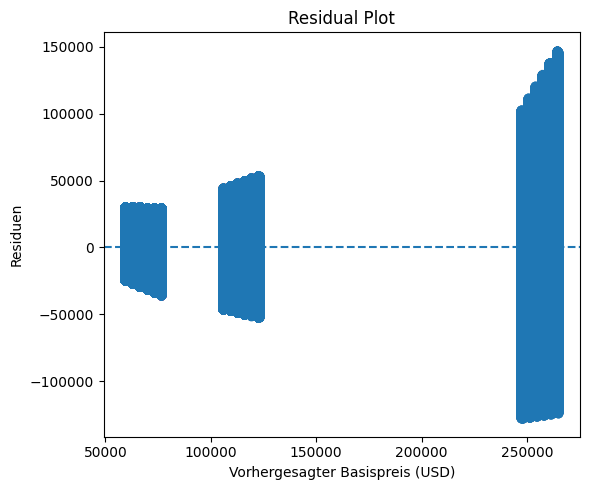

In [11]:
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(0, linestyle="--")
plt.xlabel("Vorhergesagter Basispreis (USD)")
plt.ylabel("Residuen")
plt.title("Residual Plot")

save_current_plot_mr()

plt.tight_layout()
plt.show()

- Residuen streuen überwiegend zufällig um die Nulllinie
- Keine klare systematische Struktur erkennbar
- Lineare Modellannahme insgesamt plausibel
- Größere Abweichungen treten vor allem im oberen Preissegment auf

Gespeichert: 03 Histogramm der Residuen.png


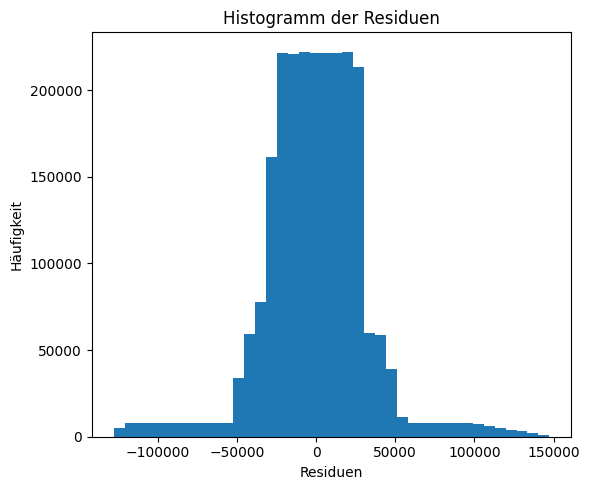

In [12]:
plt.figure(figsize=(6,5))
plt.hist(residuals, bins=40)

plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.title("Histogramm der Residuen")

save_current_plot_mr()

plt.tight_layout()
plt.show()

- Residuen konzentrieren sich um den Wert 0
- Verteilung annähernd symmetrisch
- Keine extreme Verzerrung oder starke Ausreißerstruktur
- Fehlerverteilung insgesamt stabil und für lineare Regression geeignet

In [13]:
n = X_test.shape[0]
p = X_test.shape[1]

r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
r2_adj

0.7728964098434046

# Gesamtwertung

- Das Modell erklärt rund 77 % der Varianz des Basispreises
- Die Modellreihe stellt den dominierenden Preisfaktor dar
- Technische Merkmale wie Motorleistung oder Turbo haben geringere Effekte
- Multikollinearität ist nur teilweise vorhanden und beeinflusst die Modellstabilität nicht wesentlich
- Im oberen Preissegment zeigt sich eine leichte systematische Unterschätzung
- Insgesamt liefert das Modell eine robuste und plausibel interpretierbare Preisstruktur